## Import TensorFlow and other libraries

In [1]:
import tensorflow as tf
import tensorflow_io as tfio

import os
from pathlib import Path
import time
import datetime
import numpy as np
import cv2

from matplotlib import pyplot as plt
from IPython.display import display, clear_output, update_display
from tqdm.notebook import tqdm

from joblib import Memory
from joblib import Parallel, delayed

2023-04-25 17:33:03.689555: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-04-25 17:33:03.738356: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-04-25 17:33:04.541638: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
TESTING_COHERENCE_LOSS = "l1"
TESTING_MAIN_LOSS = "l1"

# Dimensions
BATCH_SIZE = 20
IMG_WIDTH = 64
IMG_HEIGHT = 64
N_CHANNELS = 3


STEPS = 5000

LAMBDA1 = 1000
LAMBDA2 = 200

VIDEOS_FOLDER = 'mug_preprocessed'

## Load the dataset

In [3]:
PATH = Path('../data/mnist_test_seq_rgb.npy')
# load normalizer rgb data
# PATH = Path('../data/mnist_test_seq_rgb_normalized.npy')
sequences = np.load(PATH)

In [4]:
# Normalizing the images to [-1, 1]
def normalize(sequence):
  return (sequence / 127.5) - 1

# Undo normalizing the images to [0, 255]
@tf.function
def normalized_sequence_to_images(sequence):
  return tf.cast((sequence + 1) * 127.5, tf.uint8)

In [5]:
def plot_sample_sequence(sample_sequence):
    plot_sequence = list(sample_sequence)
    n_frames = len(plot_sequence)
    if n_frames > 20:
        plot_sequence = plot_sequence[:20]
        n_frames = 20
    rows = ((n_frames-1) // 10)+1
    cols = max(n_frames % 10, 10)
    fig = plt.figure(figsize=(20, 4))
    for i, im in enumerate(plot_sequence):
        ax = fig.add_subplot(rows,cols,i+1)
        ax.imshow(im) 
        ax.axis('off')
    plt.show()
    plt.close()

def plot_frame(frame, title=None):
    plt.imshow(frame)
    if title is not None:
        plt.title(title)
    plt.axis('off')
    plt.show()
    plt.close()

def plot_normalized_frame(frame, title=None):
    plot_frame(normalized_sequence_to_images(frame), title)

def sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[0]):
        yield sample_sequence[i, ...]

def plot_sequence(sample_sequence):
    plot_sample_sequence(sequence_generator(sample_sequence))

def plot_normalized_sequence(sample_sequence):
    plot_sequence(normalized_sequence_to_images(sample_sequence))

def inverse_sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[-1]):
        yield sample_sequence[..., i]

def plot_inverse_sequence(sample_sequence):
    plot_sample_sequence(inverse_sequence_generator(sample_sequence))

def plot_normalized_inverse_sequence(sample_sequence):
    plot_inverse_sequence(normalized_sequence_to_images(sample_sequence))

def plot_normalized_sequence(sample_sequence):
    plot_sequence(normalized_sequence_to_images(sample_sequence))

def plot_sequence_from_tensor(sample_sequence):
    if len(sample_sequence.shape) == 5 and sample_sequence.shape[0] == 1:
        plot_sequence(sample_sequence[0])
    else:
        raise ValueError("The tensor must be of shape (1, frames, height, width, channels)")

def plot_sequence_from_normalized_tensor(sample_sequence):
    plot_sequence_from_tensor(normalized_sequence_to_images(sample_sequence))

In [6]:
sequences = normalize(sequences)

## Build an input pipeline with `tf.keras.utils.Sequence`

In [7]:
DATASET_SIZE = sequences.shape[0]
train_size = int(0.7 * DATASET_SIZE)
# val_size = int(0.15 * DATASET_SIZE)
test_size = int(0.3 * DATASET_SIZE)

# generate training, validation and test sets
train_sequences = sequences[:train_size]
# val_sequences = sequences[train_size:train_size+val_size]
# test_sequences = sequences[train_size+val_size:]
test_sequences = sequences[train_size:]

print(train_sequences.shape)
# print(val_sequences.shape)
print(test_sequences.shape)

(7000, 20, 64, 64, 3)
(3000, 20, 64, 64, 3)


In [8]:
class FrameDataGenerator():
    
    def __init__(self, sequences, batch_size):
        n, clip_size, height, width, channels = sequences.shape
        self._sequences = sequences
        self.batch_size = batch_size
        self.n = n
        self._restart()
    
    def _load_current_video(self):
        self.current_video = self._sequences[self.current_video_index]
    
    def __iter__(self):
        return self
    
    def _load_next_video(self):
        self.current_frame_index = 1
        self.current_video_index += 1
        self._load_current_video()
    
    def _restart(self):
        self.current_video_index = 0
        self.current_frame_index = 0
        self._load_current_video()
    
    def _current_frame(self):
        return self.current_video[self.current_frame_index]
    
    def _next_frame(self):
        return self.current_video[self.current_frame_index+1]
    
    def _previous_frame(self):
        return self.current_video[self.current_frame_index-1]
    
    def _current_video_has_next_frame(self):
        return self.current_frame_index+1 < self.current_video.shape[0]
    
    def _has_current_video(self):
        return self.current_video_index < self.n
    
    def _has_next_video(self):
        return self.current_video_index+1 < self.n
    
    def _end_of_videos(self):
            raise StopIteration
    
    def _get_current_frames(self):
        return self._previous_frame(), self._current_frame(), self._next_frame()
    
    def _get_batch(self):
        batch_previous_frame = []
        batch_current_frame = []
        batch_next_frame = []
        for i in range(self.batch_size):
            previous_frame, current_frame, next_frame = self._get_current_frames()
            batch_previous_frame.append(previous_frame)
            batch_current_frame.append(current_frame)
            batch_next_frame.append(next_frame)
        return np.array(batch_previous_frame), np.array(batch_current_frame), np.array(batch_next_frame)


    def __next__(self):
        self.current_frame_index += 1 # Frame index start at one because we have to return the previous frame
        if not self._has_current_video():
            self._end_of_videos()
        while not self._current_video_has_next_frame():
            if self._has_next_video():
                self._load_next_video()
            else:
                self._end_of_videos()
        return self._get_batch()
    
    def __call__(self):
        return next(self)
    
    def take(self, n):
        for i in range(n):
            try:
                yield self()
            except StopIteration:
                self._restart()
    
    def __iter__(self):
        return self
    
    def repeat(self):
        while True:
            try:
                yield self()
            except StopIteration:
                self._restart()
    

In [9]:
train_generator = FrameDataGenerator(train_sequences, batch_size=BATCH_SIZE)
test_generator = FrameDataGenerator(test_sequences, batch_size=BATCH_SIZE)

previous_frame, current_frame, next_frame = next(test_generator)
print(previous_frame.shape)
print(current_frame.shape)
print(next_frame.shape)

(20, 64, 64, 3)
(20, 64, 64, 3)
(20, 64, 64, 3)


2023-04-25 17:33:14.110677: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13906 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:b3:00.0, compute capability: 8.6


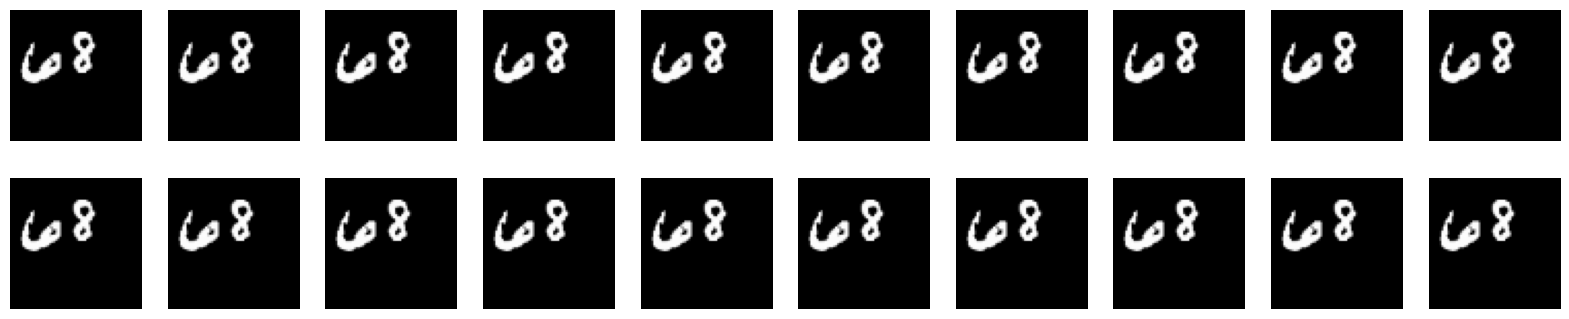

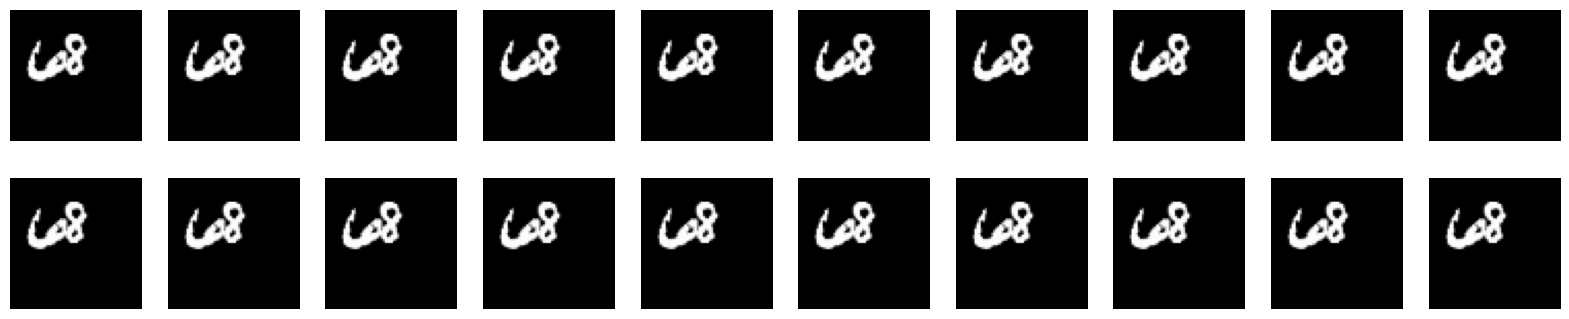

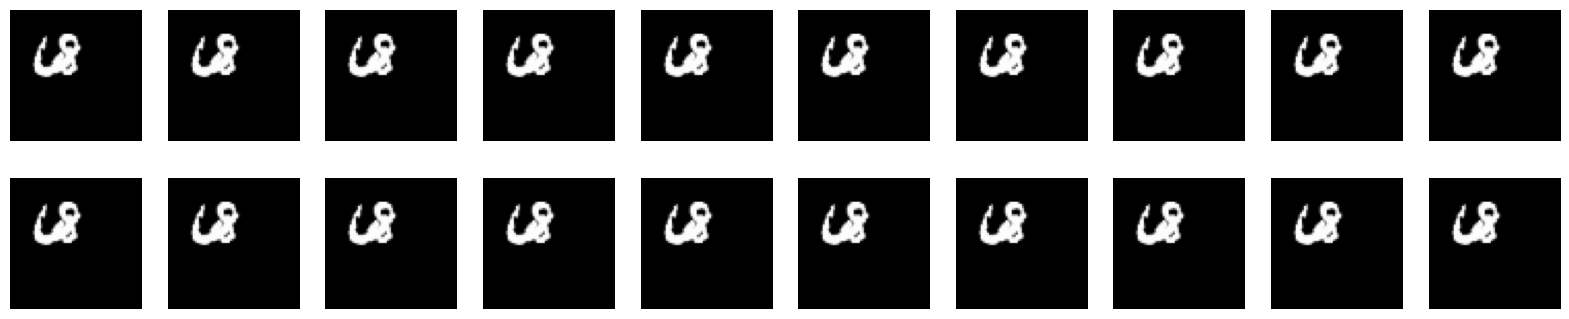

In [10]:
plot_normalized_sequence(previous_frame)
plot_normalized_sequence(current_frame)
plot_normalized_sequence(next_frame)

## Build the generator

Define the downsampler (encoder):

In [11]:
def downsample(filters, size, strides=2, apply_batchnorm=True):
  initializer = tf.random_normal_initializer(0., 0.02)

  result = tf.keras.Sequential()
  result.add(
      tf.keras.layers.Conv2D(filters, size, strides=strides, padding='same',
                             kernel_initializer=initializer, use_bias=False))

  if apply_batchnorm:
    result.add(tf.keras.layers.BatchNormalization())

  result.add(tf.keras.layers.LeakyReLU())

  return result

In [12]:
down_model = downsample(3, 4, 2)
down_result = down_model(current_frame, 0)
print (down_result.shape)

2023-04-25 17:33:17.619775: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8600


(20, 32, 32, 3)


Define the upsampler (decoder):

In [13]:
def upsample(filters, size, strides=2, apply_dropout=False):
  initializer = tf.random_normal_initializer(0., 0.02)

  result = tf.keras.Sequential()
  result.add(
    tf.keras.layers.Conv2DTranspose(filters, size, strides=strides,
                                    padding='same',
                                    kernel_initializer=initializer,
                                    use_bias=False))

  result.add(tf.keras.layers.BatchNormalization())

  if apply_dropout:
      result.add(tf.keras.layers.Dropout(0.5))

  result.add(tf.keras.layers.ReLU())

  return result

In [14]:
up_model = upsample(3, 4, 2)
up_result = up_model(down_result)
print (up_result.shape)
print(current_frame.shape)

(20, 64, 64, 3)
(20, 64, 64, 3)


In [15]:
def Generator():
  inputs = tf.keras.layers.Input(shape=[IMG_WIDTH, IMG_HEIGHT, N_CHANNELS], dtype=tf.float64)

  down_stack = [
    downsample(128, 4, 2, apply_batchnorm=False),  # (batch_size, frames_group_size, 32, 32, 128)
    downsample(128, 4, 2),  # (batch_size, frames_group_size, 16, 16, 128)
    downsample(256, 4, 2),  # (batch_size, frames_group_size, 8, 8, 256)
    downsample(512, 4, 2),  # (batch_size, frames_group_size, 4, 4, 512)
    downsample(512, 4, 2),  # (batch_size, frames_group_size, 2, 2, 512)
  ]

  up_stack = [
    upsample(512, 4, 2, apply_dropout=False),  # (batch_size, frames_group_size, 4, 4, 512)
    # upsample(512, 4, 2, apply_dropout=True),  # (batch_size, frames_group_size, 4, 4, 512)
    upsample(256, 4, 2),  # (batch_size, frames_group_size, 8, 8, 256)
    upsample(128, 4, 2),  # (batch_size, frames_group_size, 16, 16, 256)
    upsample(128, 4, 2),  # (batch_size, frames_group_size, 32, 32, 128)
  ]

  initializer = tf.random_normal_initializer(0., 0.02)
  last = tf.keras.layers.Conv2DTranspose(N_CHANNELS, 4,
                                         strides=2,
                                         padding='same',
                                         kernel_initializer=initializer,
                                         activation='tanh')  # (batch_size, , frames_group_size, 64, 64, 3)

  x = inputs

  # Downsampling through the model
  skips = []
  for down in down_stack:
    x = down(x)
    skips.append(x)

  skips = reversed(skips[:-1])

  # Upsampling and establishing the skip connections
  for up, skip in zip(up_stack, skips):
    x = up(x)
    x = tf.keras.layers.Concatenate()([x, skip])

  x = last(x)

  return tf.keras.Model(inputs=inputs, outputs=x)

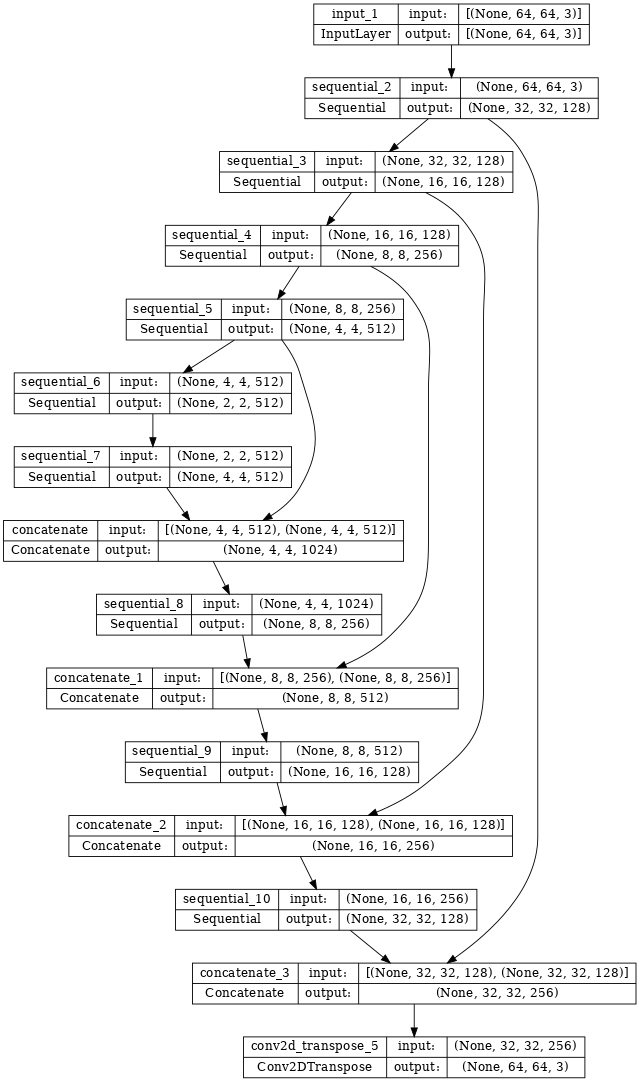

In [16]:
generator = Generator()
tf.keras.utils.plot_model(generator, show_shapes=True, dpi=64, to_file='output/generator.png')

Test the generator:

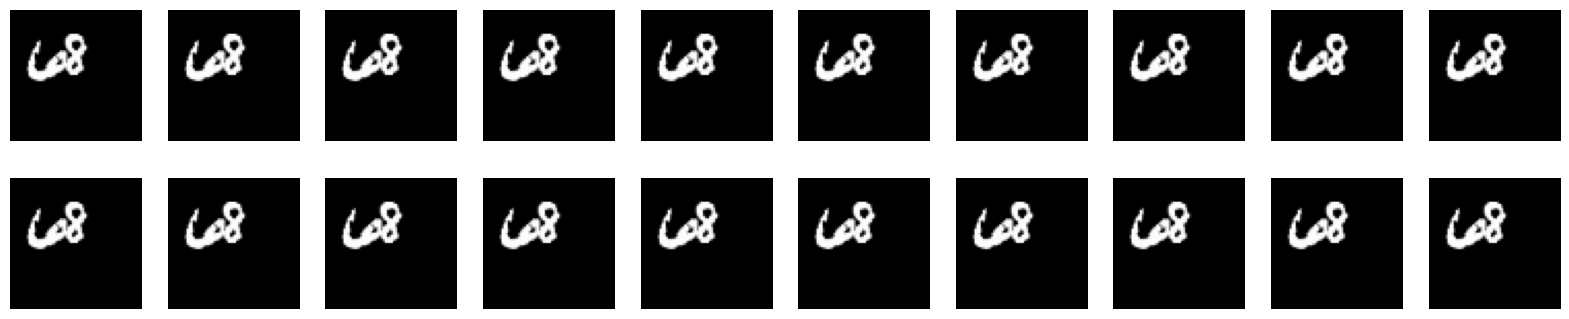

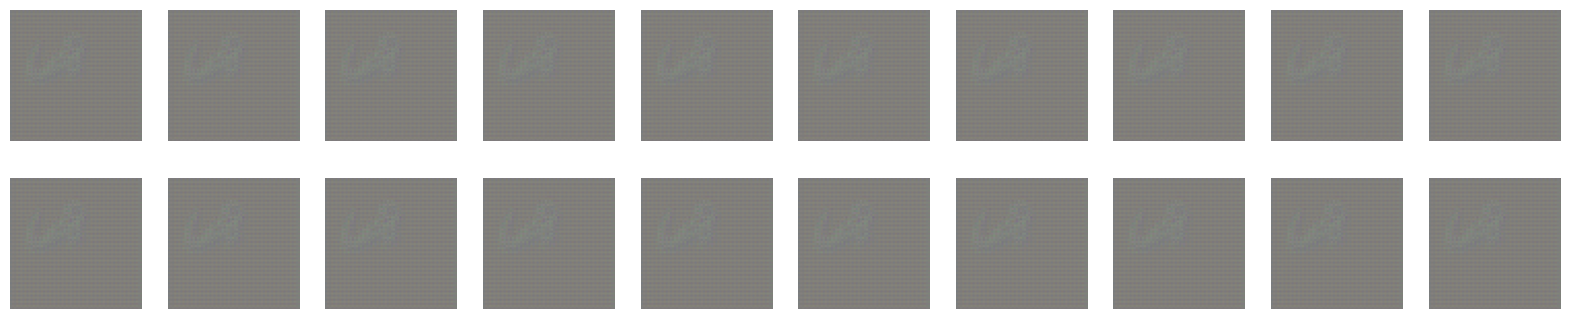

In [17]:
get_outputs =  generator(current_frame, training=False)

plot_normalized_sequence(current_frame)
plot_normalized_sequence(get_outputs)

### Define the generator loss

In [18]:
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [19]:
@tf.function
def l1_loss(previous, current):
  return  tf.math.abs(current-previous)

@tf.function
def get_luminance(image):
  output = normalized_sequence_to_images(image)
  output = tfio.experimental.color.rgb_to_ycbcr(output)
  output = output[...,0] # get y from ycbcr
  return tf.cast(output, tf.float32)

@tf.function
def apply_luminance_loss(previous, current, loss_function):
  previous_luminance = get_luminance(previous)
  current_luminance = get_luminance(current)
  return loss_function(previous_luminance, current_luminance)
  

@tf.function
def mean_loss(y_true, y_pred, loss_function):
  y_true = tf.cast(y_true, tf.float32)
  y_pred = tf.cast(y_pred, tf.float32)
  return tf.math.reduce_mean(loss_function(y_true, y_pred))

@tf.function
def coherence_mean_loss(previous_y_true, y_true, previous_y_pred, y_pred, loss_function):
  loss_true = apply_luminance_loss(previous_y_true, y_true, loss_function)
  loss_pred = apply_luminance_loss(previous_y_pred, y_pred, loss_function)
  return tf.math.reduce_mean(tf.abs(loss_true - loss_pred))

## Comparing loss functions

In [20]:
GENERATOR_LOSS_FUNCTIONS = {
    'l1': l1_loss,
}

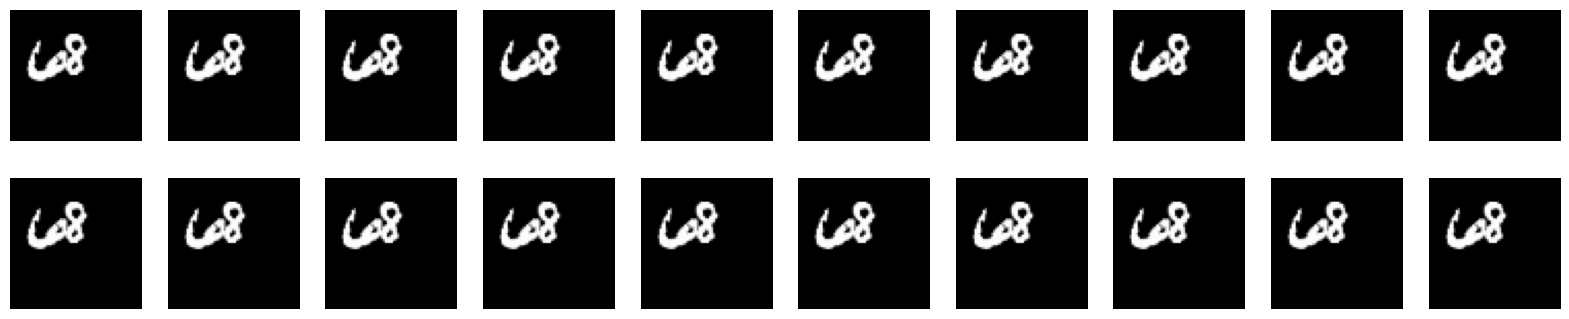

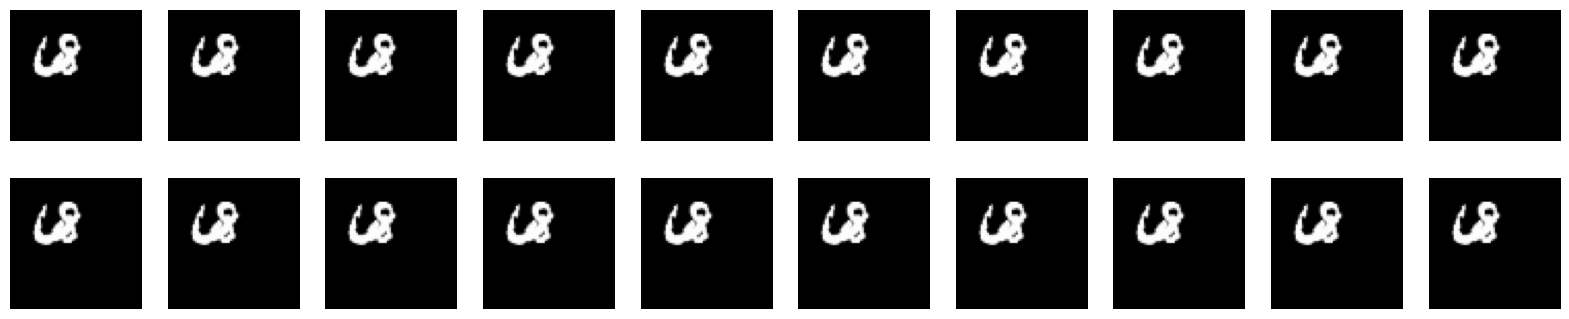

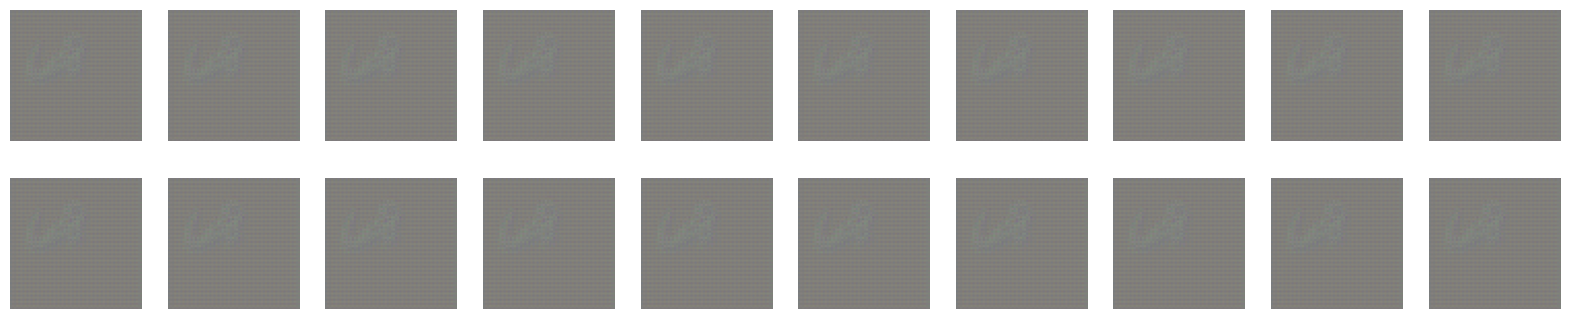

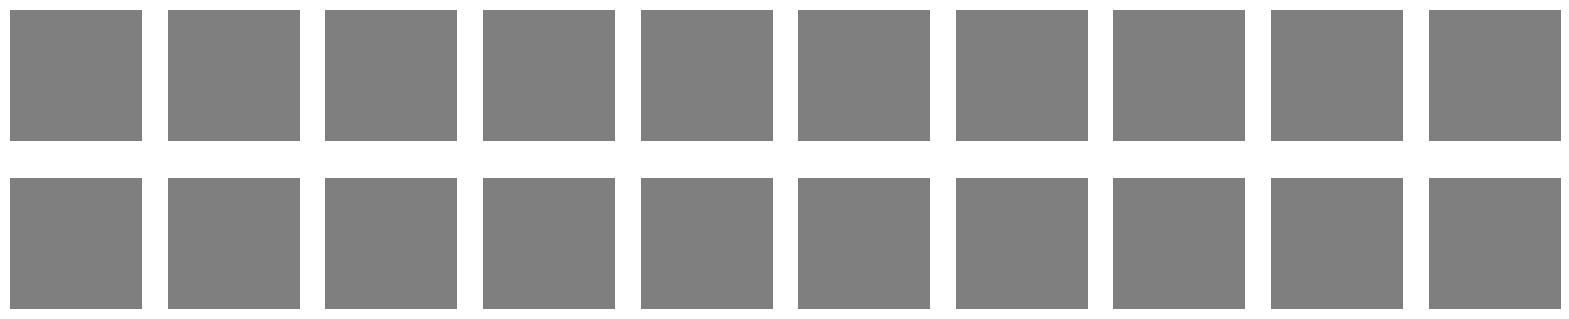

current_frame float32
next_frame float32
gen_output_sample <dtype: 'float32'>
gen_output_next_sample <dtype: 'float32'>


In [21]:
gen_output_sample = generator(current_frame, training=False)
gen_output_next_sample = generator(gen_output_sample, training=False)
plot_normalized_sequence(current_frame)
plot_normalized_sequence(next_frame)
plot_normalized_sequence(gen_output_sample)
plot_normalized_sequence(gen_output_next_sample)

# print types
print("current_frame", current_frame.dtype)
print("next_frame", next_frame.dtype)
print("gen_output_sample", gen_output_sample.dtype)
print("gen_output_next_sample", gen_output_next_sample.dtype)

In [22]:
for loss_function in GENERATOR_LOSS_FUNCTIONS:
    print("================================", loss_function, "================================")
    loss_value = mean_loss(next_frame,gen_output_sample,GENERATOR_LOSS_FUNCTIONS[loss_function])
    print(loss_value)

================================ l1 ================================
tf.Tensor(0.97478956, shape=(), dtype=float32)


In [23]:
for loss_function in GENERATOR_LOSS_FUNCTIONS:
    print("================================", loss_function, "================================")
    loss_value = coherence_mean_loss(current_frame, next_frame, gen_output_sample, gen_output_next_sample, GENERATOR_LOSS_FUNCTIONS[loss_function])
    print(loss_value)

================================ l1 ================================
tf.Tensor(14.825684, shape=(), dtype=float32)


2023-04-25 17:33:25.353010: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:637] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


In [24]:
def generator_loss(disc_generated_output, previous_gen, current_gen, previous_target, current_target):
  gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)

  if TESTING_COHERENCE_LOSS:
    coherence_loss = coherence_mean_loss(previous_target, current_target, previous_gen, current_gen, GENERATOR_LOSS_FUNCTIONS[loss_function]) * LAMBDA2
  else:
    coherence_loss = 0

  # Mean absolute error
  main_loss = mean_loss(current_target, current_gen, GENERATOR_LOSS_FUNCTIONS[TESTING_MAIN_LOSS]) * LAMBDA1

  total_gen_loss = gan_loss + main_loss + coherence_loss

  return total_gen_loss, gan_loss, main_loss, coherence_loss

Comparing new loss function

## Build the discriminator

Let's define the discriminator:

In [25]:
def Discriminator():
  initializer = tf.random_normal_initializer(0., 0.02)

  inp = tf.keras.layers.Input(shape=[IMG_WIDTH, IMG_HEIGHT, N_CHANNELS], name='current_frame')
  tar = tf.keras.layers.Input(shape=[IMG_WIDTH, IMG_HEIGHT, N_CHANNELS], name='folowing_frame')

  x = tf.keras.layers.concatenate([inp, tar])  # (batch_size, 256, 256, channels*2)

  down1 = downsample(64, 4, 2, apply_batchnorm=False)(x)  # (batch_size, 128, 128, 64)
  down2 = downsample(128, 4, 2)(down1)  # (batch_size, 64, 64, 128)
  # down3 = downsample(256, 4)(down2)  # (batch_size, 32, 32, 256)

  zero_pad1 = tf.keras.layers.ZeroPadding2D()(down2)  # (batch_size, 34, 34, 256)
  conv = tf.keras.layers.Conv2D(256, 4, strides=1,
                                kernel_initializer=initializer,
                                use_bias=False)(zero_pad1)  # (batch_size, 31, 31, 512)

  batchnorm1 = tf.keras.layers.BatchNormalization()(conv)

  leaky_relu = tf.keras.layers.LeakyReLU()(batchnorm1)

  zero_pad2 = tf.keras.layers.ZeroPadding2D()(leaky_relu)  # (batch_size, 33, 33, 512)

  last = tf.keras.layers.Conv2D(1, 2, strides=1,
                                kernel_initializer=initializer)(zero_pad2)  # (batch_size, 30, 30, 1)

  return tf.keras.Model(inputs=[inp, tar], outputs=last)

Visualize the discriminator model architecture:

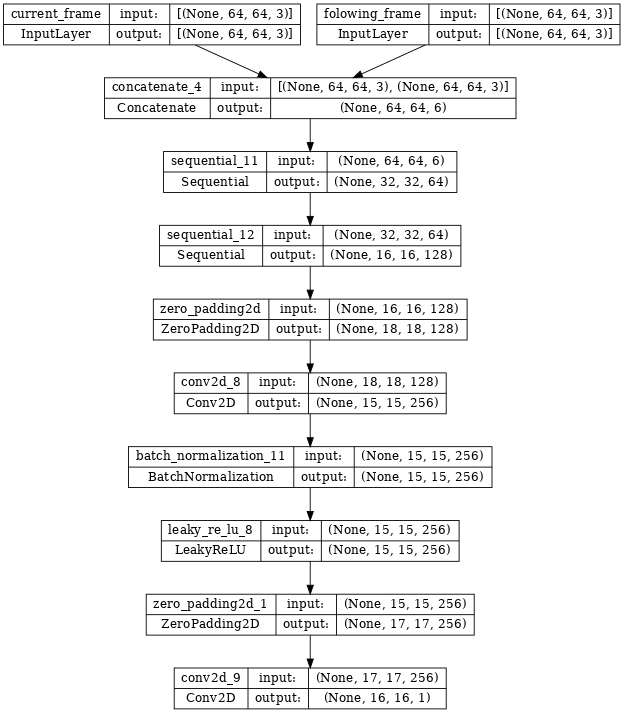

In [26]:
discriminator = Discriminator()
tf.keras.utils.plot_model(discriminator, show_shapes=True, dpi=64, to_file='output/discriminator.png')

Test the discriminator:

(20, 16, 16, 1)


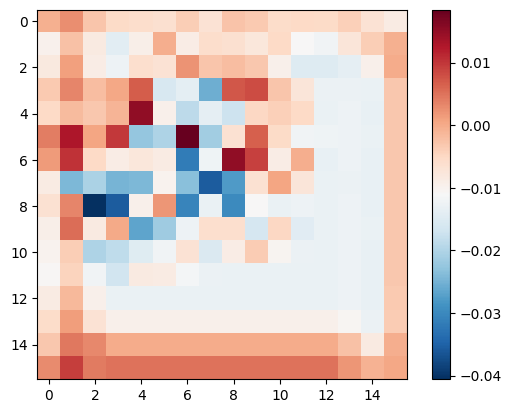

In [27]:
disc_out = discriminator([current_frame, gen_output_sample], training=False)
print(disc_out.shape)
plt.imshow(disc_out[0, ..., -1], cmap='RdBu_r')
plt.colorbar()
plt.show()
plt.close()

### Define the discriminator loss

In [28]:
def discriminator_loss(disc_real_output, disc_generated_output):
  real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)

  generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)

  total_disc_loss = real_loss + generated_loss

  return total_disc_loss

## Define the optimizers and a checkpoint-saver


In [29]:
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

In [30]:
BASE_DIR = f'output/'
checkpoint_dir = str(Path(BASE_DIR) /  f'{TESTING_MAIN_LOSS}_{LAMBDA1}_{TESTING_COHERENCE_LOSS}_{LAMBDA2}' / 'training_checkpoints')
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

## Generate images

Note: The `training=True` is intentional here since you want the batch statistics, while running the model on the test dataset. If you use `training=False`, you get the accumulated statistics learned from the training dataset (which you don't want).

In [31]:
def plot_results(sample_target, sample_input, gen_output):

  display_list = [sample_input, sample_target, gen_output]
  title = ['Input Sequence', 'Ground Truth', 'Predicted Sequence']

  for i in range(3):
    print(title[i])
    display_list[i] = display_list[i]
    plot_normalized_sequence(display_list[i])

def generate_sequences(model, sample_target, sample_input):
  prediction = model(sample_input, training=True)
  plot_results(sample_input, sample_target, prediction)

Test the function:

Input Sequence


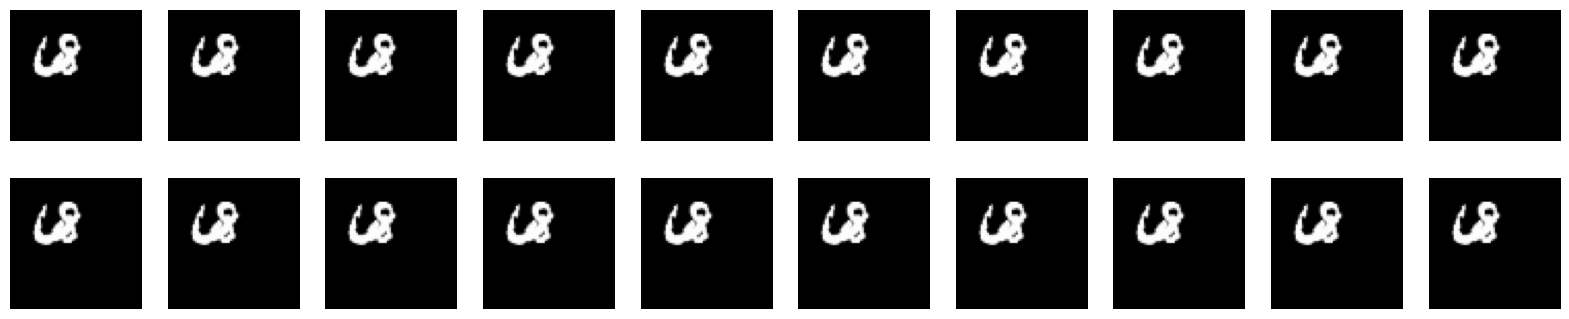

Ground Truth


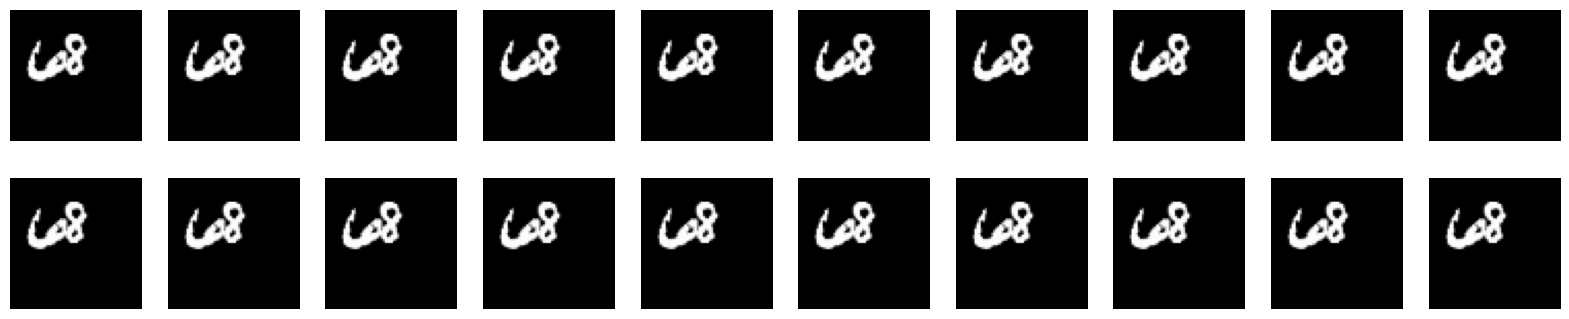

Predicted Sequence


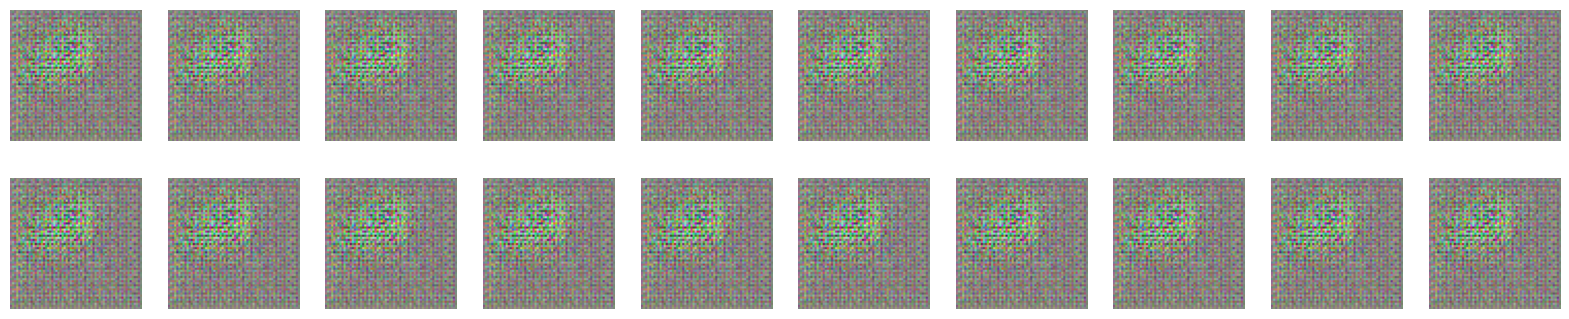

In [32]:
generate_sequences(generator, next_frame, current_frame)

## Training


In [33]:
log_dir=Path(BASE_DIR) / "logs/"
log_file = log_dir / "fit" / datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

summary_writer = tf.summary.create_file_writer(str(log_file))

In [34]:
@tf.function
def train_step(previous_frame, current_frame, next_frame, step):
  with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
    previous_gen_output = generator(previous_frame, training=True)
    current_gen_output = generator(current_frame, training=True)

    disc_real_output = discriminator([current_frame, next_frame], training=True)
    disc_generated_output = discriminator([current_frame, current_gen_output], training=True)
    
    gen_total_loss, gen_gan_loss, gen_target_predicted, gen_coherence_loss = generator_loss(
      disc_generated_output, previous_gen_output, current_gen_output, current_frame, next_frame
    )

    
    disc_loss = discriminator_loss(disc_real_output, disc_generated_output)

  generator_gradients = gen_tape.gradient(gen_total_loss,
                                          generator.trainable_variables)
  discriminator_gradients = disc_tape.gradient(disc_loss,
                                               discriminator.trainable_variables)

  generator_optimizer.apply_gradients(zip(generator_gradients,
                                          generator.trainable_variables))
  discriminator_optimizer.apply_gradients(zip(discriminator_gradients,
                                              discriminator.trainable_variables))

  with summary_writer.as_default():
    summary_step = step//1000
    tf.summary.scalar(f'gen_total_loss', gen_total_loss, step=summary_step)
    tf.summary.scalar(f'gen_gan_loss', gen_gan_loss, step=summary_step)
    tf.summary.scalar(f'gen_target_predicted_{TESTING_MAIN_LOSS}', gen_target_predicted, step=summary_step)
    if TESTING_COHERENCE_LOSS:
      tf.summary.scalar(f'gen_coherence_{TESTING_COHERENCE_LOSS}', gen_coherence_loss, step=summary_step)
    tf.summary.scalar(f'disc_loss', disc_loss, step=summary_step)

In [35]:
def fit(train_dataset_generator, previous_frame_ex, current_frame_ex, next_frame_ex, steps):

  train_dataset = train_dataset_generator.take(steps)
  pbar = tqdm(range(steps), total=steps)
  for step in pbar:
    with tf.profiler.experimental.Trace('train', step_num=step, _r=1):
      previous_frame, current_frame, next_frame = next(train_dataset)

      if (step) % 1000 == 0:
        clear_output(wait=True)
        display(pbar.container)
        generate_sequences(generator, current_frame_ex, next_frame_ex)
        print("Working on input:")
        plot_normalized_sequence(current_frame)
        print("Working on target:")
        plot_normalized_sequence(next_frame)

      train_step(previous_frame, current_frame, next_frame, step)

      # Save (checkpoint) the model every 5k steps
      if (step + 1) % 5000 == 0:
          checkpoint.save(file_prefix=checkpoint_prefix)

In [36]:
previous_frame_ex, current_frame_ex, next_frame_ex = next(test_generator)

Restart datatset generator from begining

In [37]:
train_generator = FrameDataGenerator(train_sequences, batch_size=BATCH_SIZE)

 20%|##        | 1000/5000 [28:44<1:54:18,  1.71s/it]

Input Sequence


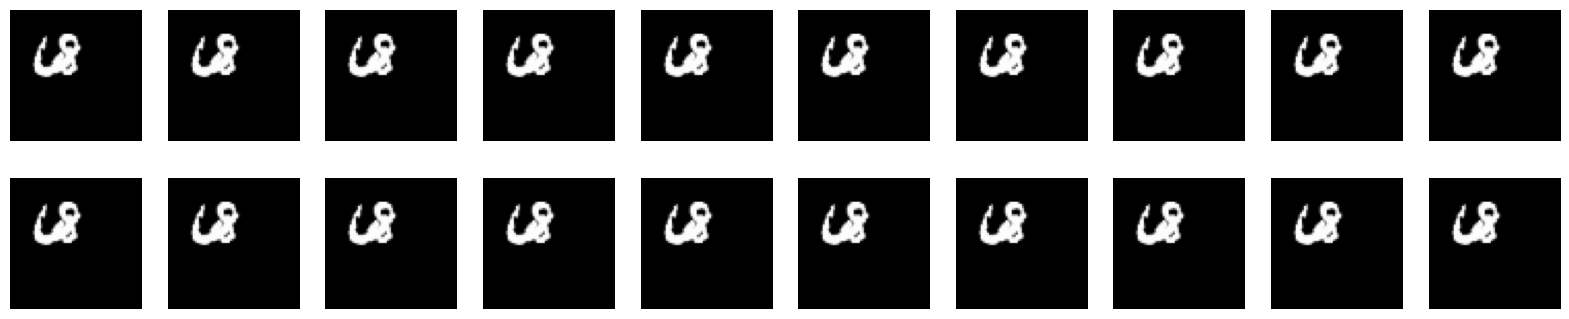

Ground Truth


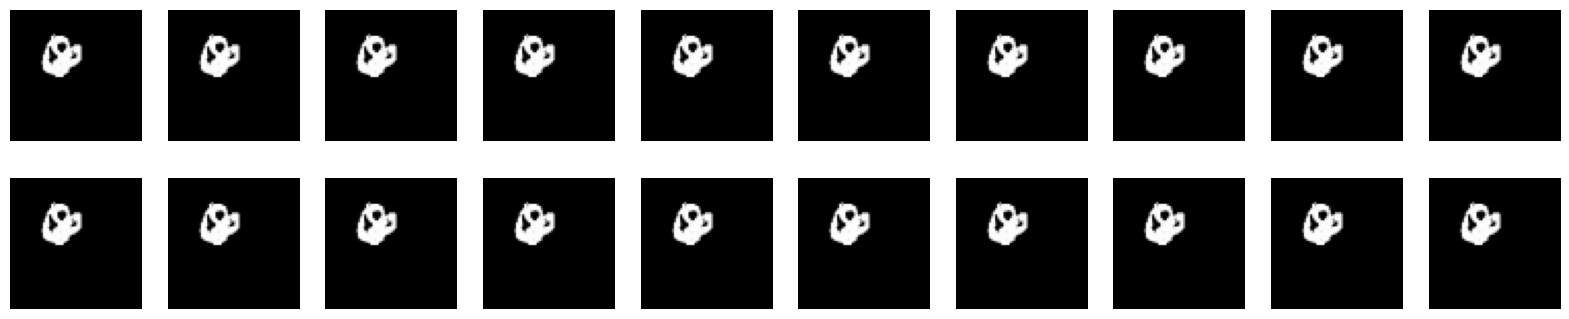

Predicted Sequence


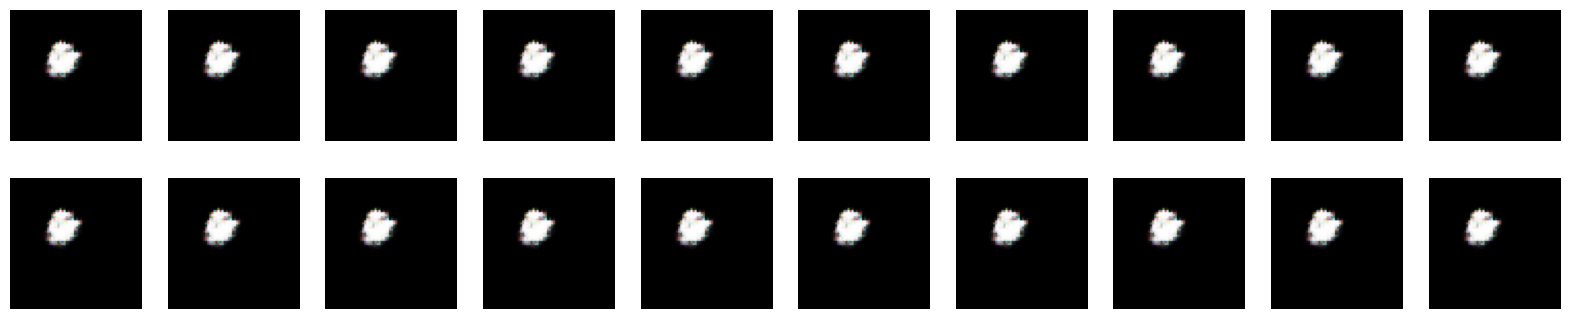

Working on input:


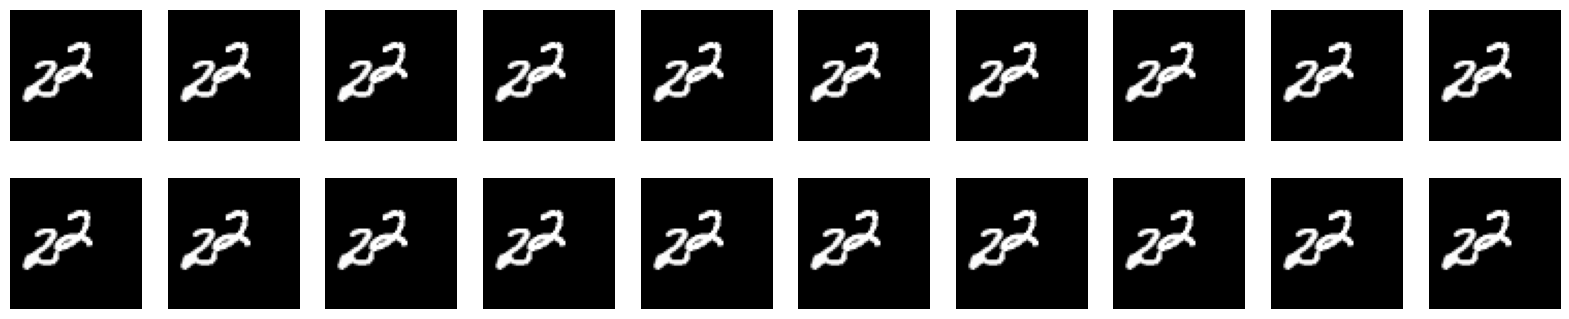

Working on target:


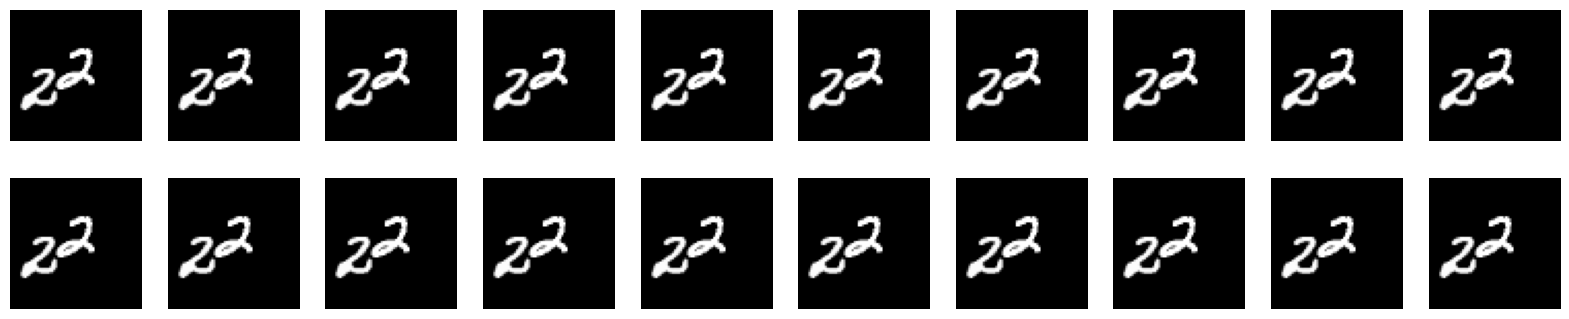

In [38]:
tf.profiler.experimental.start(str(log_dir))
fit(train_generator, previous_frame_ex, current_frame_ex, next_frame_ex, steps=STEPS)
tf.profiler.experimental.stop()

## Restore the latest checkpoint and test the network

In [ ]:
!ls {checkpoint_dir}

In [ ]:
# Restoring the latest checkpoint in checkpoint_dir
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

## Generate some images using the test set

In [ ]:
test_generator = FrameDataGenerator(test_paths, batch_size=BATCH_SIZE)

for i in range(0,10):
  previous_frame, current_frame, next_frame = next(test_generator)
  predicted_output = generator(current_frame, training=False)
  plot_results(current_frame, next_frame, predicted_output)

In [ ]:
# evaluating the results with SSIM
def evaluate_metrics(target_sequence, generated_output):
    #cast to float32
    target_sequence = tf.cast(target_sequence, tf.float32)
    generated_output = tf.cast(generated_output, tf.float32)
    #compute ssim
    ssim_score = tf.image.ssim(generated_output, target_sequence, max_val=1)
    #compute psnr
    psnr_score = tf.image.psnr(generated_output, target_sequence, max_val=1)
    #compute mse
    mse_score = tf.keras.losses.MSE(generated_output, target_sequence)
    #compute l1
    l1_score = tf.keras.losses.MAE(generated_output, target_sequence)
    return ssim_score, psnr_score, mse_score, l1_score


ssim_scores = []
psnr_scores = []
mse_scores = []
l1_scores = []

test_generator = FrameDataGenerator(test_sequences)
test_frames = np.array(list(test_generator))

batch = 1000
for i in tqdm(range(0, len(test_frames), batch)):
  input_frames = test_frames[i:i+batch,1,:,:,:]
  target_frames = test_frames[i:i+batch,2,0,:,:]
  predicted_frames = np.array([generator(f, training=False) for f in input_frames])[:,0,...]
  ssim_score, psnr_score, mse_score, l1_score = evaluate_metrics(target_frames, predicted_frames)
  ssim_scores.extend(ssim_score)
  psnr_scores.extend(psnr_score)
  mse_scores.extend(mse_score)
  l1_scores.extend(l1_score)

In [ ]:
scores = {
    "SSIM": ssim_scores,
    "PSNR": psnr_scores,
    "MSE": mse_scores,
    "L1": l1_scores,
}

score_string = ""
for score_name in scores.keys():
    mean = tf.math.reduce_mean(scores[score_name])
    print(f"{score_name} score: {mean}")
    score_string += f"{mean}\t"

print(score_string)

## Different order

In [ ]:
new_order = [0, 10, 1, 11, 2, 12, 3, 13, 4, 14, 5, 15, 6, 16, 7, 17, 8, 18, 9]

# # Run the trained model on a few examples from the test set
# for i, (inp, tar) in enumerate(test_dataset.take(5)):
#   inp = tf.gather(inp, new_order, axis=-1)
#   tar = tf.gather(tar, new_order, axis=-1)
#   # inp = inp[..., new_order]
#   # tar = tar[..., new_order]
#   print(i)
#   generate_sequences(generator, inp, tar, save_dir=save_dir)